In [22]:
# %pip install pandas
# %pip install openpyxl
# %pip install seaborn
# %pip install matplotlib
%pip install streamlit

  Using cached streamlit-1.57.0-py3-none-any.whl.metadata (9.6 kB)
  Using cached altair-6.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached cachetools-7.1.4-py3-none-any.whl.metadata (5.5 kB)
  Using cached click-8.4.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached gitpython-3.1.50-py3-none-any.whl.metadata (14 kB)
  Using cached pydeck-0.9.2-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached protobuf-7.35.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached pyarrow-24.0.0-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached starlette-1.0.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached uvicorn-0.47.0-py3-none-any.whl.metadata 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd

In [12]:
df = pd.read_excel("datasets\Pokemon.xlsx")
df.head()

<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\hetse\AppData\Local\Temp\ipykernel_5744\3967916501.py:1: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  df = pd.read_excel("datasets\Pokemon.xlsx")


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,Ninguno,309,39,52,43,60,50,65,1,False


# Análisis exploratorio (EDA) - Pokemon.xlsx

Este notebook realiza un análisis exploratorio del dataset `datasets/Pokemon.xlsx`.
Se incluyen: descripción de columnas, valores faltantes, estadísticas básicas, distribuciones, mapas de correlación y tablas resumen por tipo. Ejecuta las celdas en orden para generar los resultados.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [14]:
# Información general del dataframe
print('Shape:', df.shape)
print('Columns:')
print(list(df.columns))
print('Dtypes:')
print(df.dtypes)
print('Info:')
df.info()

Shape: (800, 13)
Columns:
['#', 'Name', 'Type 1', 'Type 2', 'Total', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']
Dtypes:
#             int64
Name            str
Type 1          str
Type 2          str
Total         int64
HP            int64
Attack        int64
Defense       int64
Sp. Atk       int64
Sp. Def       int64
Speed         int64
Generation    int64
Legendary      bool
dtype: object
Info:
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   #           800 non-null    int64
 1   Name        800 non-null    str  
 2   Type 1      800 non-null    str  
 3   Type 2      800 non-null    str  
 4   Total       800 non-null    int64
 5   HP          800 non-null    int64
 6   Attack      800 non-null    int64
 7   Defense     800 non-null    int64
 8   Sp. Atk     800 non-null    int64
 9   Sp. Def     800 non-null    in

In [15]:
# Estadísticas descriptivas (numéricas y categóricas)
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
#,800.0,NaN,NaN,NaN,362.81375,208.343798,1.0,184.75,364.5,539.25,721.0
Name,800,800,Bulbasaur,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type 1,800,18,Water,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type 2,800,19,Ninguno,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total,800.0,NaN,NaN,NaN,435.1025,119.96304,180.0,330.0,450.0,515.0,780.0
HP,800.0,NaN,NaN,NaN,69.25875,25.534669,1.0,50.0,65.0,80.0,255.0
Attack,800.0,NaN,NaN,NaN,79.00125,32.457366,5.0,55.0,75.0,100.0,190.0
Defense,800.0,NaN,NaN,NaN,73.8425,31.183501,5.0,50.0,70.0,90.0,230.0
Sp. Atk,800.0,NaN,NaN,NaN,72.82,32.722294,10.0,49.75,65.0,95.0,194.0
Sp. Def,800.0,NaN,NaN,NaN,71.9025,27.828916,20.0,50.0,70.0,90.0,230.0


In [16]:
# Valores faltantes por columna
missing = df.isnull().sum()
missing[missing>0].sort_values(ascending=False)

Series([], dtype: int64)

In [17]:
# Conteos para columnas categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    print(f'--- {c} ---')
    print(df[c].value_counts(dropna=False).head(10))
    print()

--- Name ---
Name
Bulbasaur                    1
Ivysaur                      1
Venusaur                     1
VenusaurMega Venusaur        1
Charmander                   1
Charmeleon                   1
Charizard                    1
CharizardMega Charizard X    1
CharizardMega Charizard Y    1
Squirtle                     1
Name: count, dtype: int64

--- Type 1 ---
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Name: count, dtype: int64

--- Type 2 ---
Type 2
Ninguno     386
Flying       97
Ground       35
Poison       34
Psychic      33
Fighting     26
Grass        25
Fairy        23
Steel        22
Dark         20
Name: count, dtype: int64



C:\Users\hetse\AppData\Local\Temp\ipykernel_5744\847353039.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


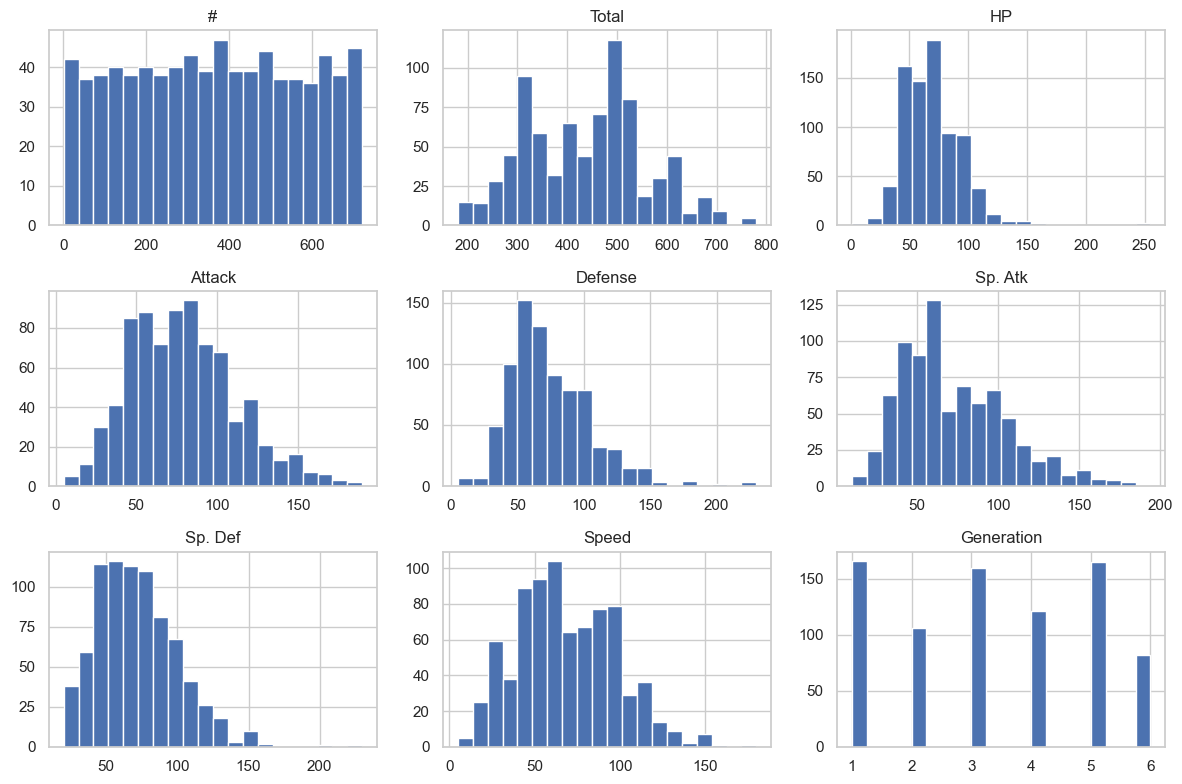

In [18]:
# Distribuciones de columnas numéricas (histogramas)
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
if len(num_cols):
    df[num_cols].hist(bins=20, figsize=(12,8), layout=(max(1, (len(num_cols)//3)),3))
    plt.tight_layout()

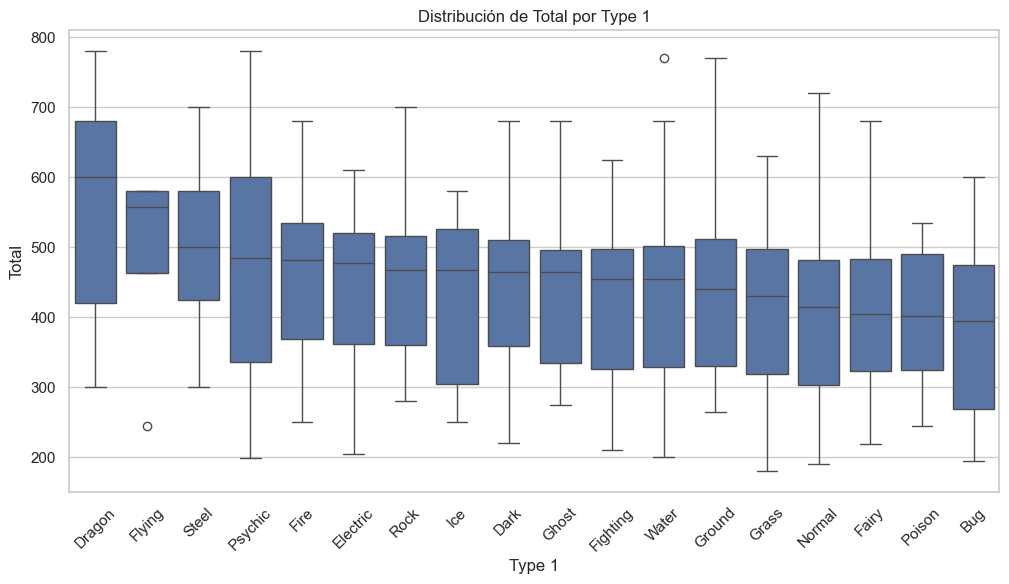

In [19]:
# Boxplot de 'Total' por 'Type 1' (si existen)
if 'Type 1' in df.columns and 'Total' in df.columns:
    plt.figure(figsize=(12,6))
    order = df.groupby('Type 1')['Total'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='Type 1', y='Total', order=order)
    plt.xticks(rotation=45)
    plt.title('Distribución de Total por Type 1')
    plt.show()

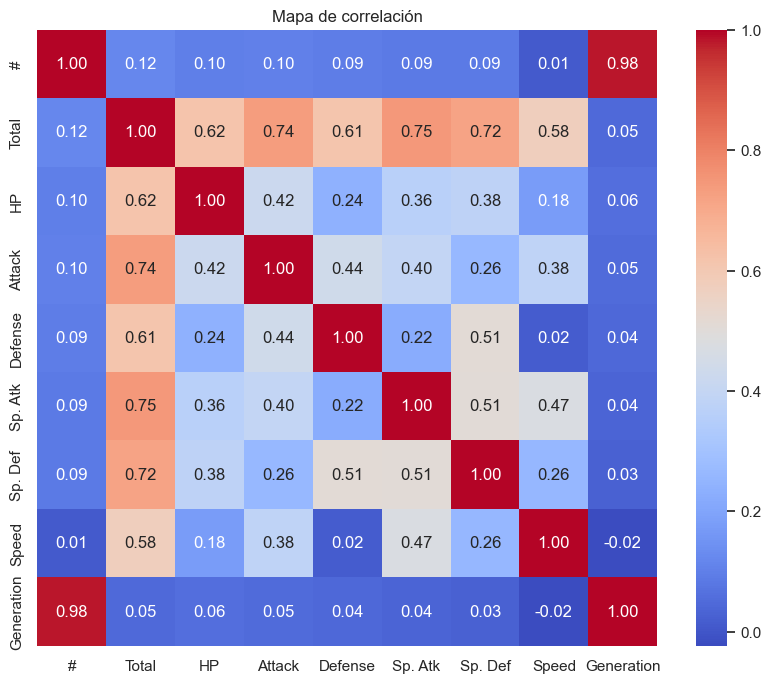

In [20]:
# Mapa de correlación entre variables numéricas
if len(num_cols)>1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Mapa de correlación')
    plt.show()

In [21]:
# Top 10 por 'Total' y resumen por tipo (si existen)
if 'Total' in df.columns:
    display(df.sort_values('Total', ascending=False).head(10))
    if 'Type 1' in df.columns:
        display(df.groupby('Type 1')[num_cols].mean().sort_values('Total', ascending=False))

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
426,384,RayquazaMega Rayquaza,Dragon,Flying,780,105,180,100,180,100,115,3,True
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True
164,150,MewtwoMega Mewtwo Y,Psychic,Ninguno,780,106,150,70,194,120,140,1,True
422,382,KyogrePrimal Kyogre,Water,Ninguno,770,100,150,90,180,160,90,3,True
424,383,GroudonPrimal Groudon,Ground,Fire,770,100,180,160,150,90,90,3,True
552,493,Arceus,Normal,Ninguno,720,120,120,120,120,120,120,4,True
418,380,LatiasMega Latias,Dragon,Psychic,700,80,100,120,140,150,110,3,True
494,445,GarchompMega Garchomp,Dragon,Ground,700,108,170,115,120,95,92,4,False
413,376,MetagrossMega Metagross,Steel,Psychic,700,80,145,150,105,110,110,3,False
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True


,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
Type 1,,,,,,,,,
Dragon,474.375000,550.531250,83.312500,112.125000,86.375000,96.843750,88.843750,83.031250,3.875000
Steel,442.851852,487.703704,65.222222,92.703704,126.370370,67.518519,80.629630,55.259259,3.851852
Flying,677.750000,485.000000,70.750000,78.750000,66.250000,94.250000,72.500000,102.500000,5.500000
Psychic,380.807018,475.947368,70.631579,71.456140,67.684211,98.403509,86.280702,81.491228,3.385965
Fire,327.403846,458.076923,69.903846,84.769231,67.769231,88.980769,72.211538,74.442308,3.211538
Rock,392.727273,453.750000,65.363636,92.863636,100.795455,63.340909,75.477273,55.909091,3.454545
Dark,461.354839,445.741935,66.806452,88.387097,70.225806,74.645161,69.516129,76.161290,4.032258
Electric,363.500000,443.409091,59.795455,69.090909,66.295455,90.022727,73.704545,84.500000,3.272727
Ghost,486.500000,439.562500,64.437500,73.781250,81.187500,79.343750,76.468750,64.343750,4.187500


## Observaciones iniciales (ejemplo)

- Ejecuta las celdas anteriores para obtener números exactos sobre filas, columnas y valores faltantes.
- En datasets de Pokémon normalmente la columna `Total` está altamente correlacionada con `HP`, `Attack`, `Defense`, `Sp. Atk`, `Sp. Def` y `Speed` (suma de estadísticas).
- Analiza `Type 1` y `Type 2` para ver diferencias de medias entre tipos y detectar outliers.
- Si necesitas un análisis más detallado (modelado, clustering o reducción de dimensionalidad), dímelo y lo añado.